In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


## Informasi Dataset

In [ ]:
import os
print("Folder dataset:", os.listdir(path))

Folder dataset: ['PetImages', 'readme[1].txt', 'MSR-LA - 3467.docx']


In [ ]:
pet_images_path = os.path.join(path, 'PetImages')
print("Folder PetImages:", os.listdir(pet_images_path))

Folder PetImages: ['Dog', 'Cat']


In [ ]:
import os

if 'path' in globals():
    root_dataset_path = path

pet_images_path = os.path.join(root_dataset_path, "PetImages")
cat_path = os.path.join(pet_images_path, "Cat")
dog_path = os.path.join(pet_images_path, "Dog")

def count_files_in_directory(directory):
    count = 0
    if os.path.exists(directory):
        for root, dirs, files in os.walk(directory):
            count += len(files)
    return count


print(f"{root_dataset_path} {count_files_in_directory(root_dataset_path)} files")
print(f"{pet_images_path} {count_files_in_directory(pet_images_path)} files")
print(f"{cat_path} {count_files_in_directory(cat_path)} files")
print(f"{dog_path} {count_files_in_directory(dog_path)} files")

/kaggle/input/microsoft-catsvsdogs-dataset 25004 files
/kaggle/input/microsoft-catsvsdogs-dataset/PetImages 25002 files
/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat 12501 files
/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog 12501 files


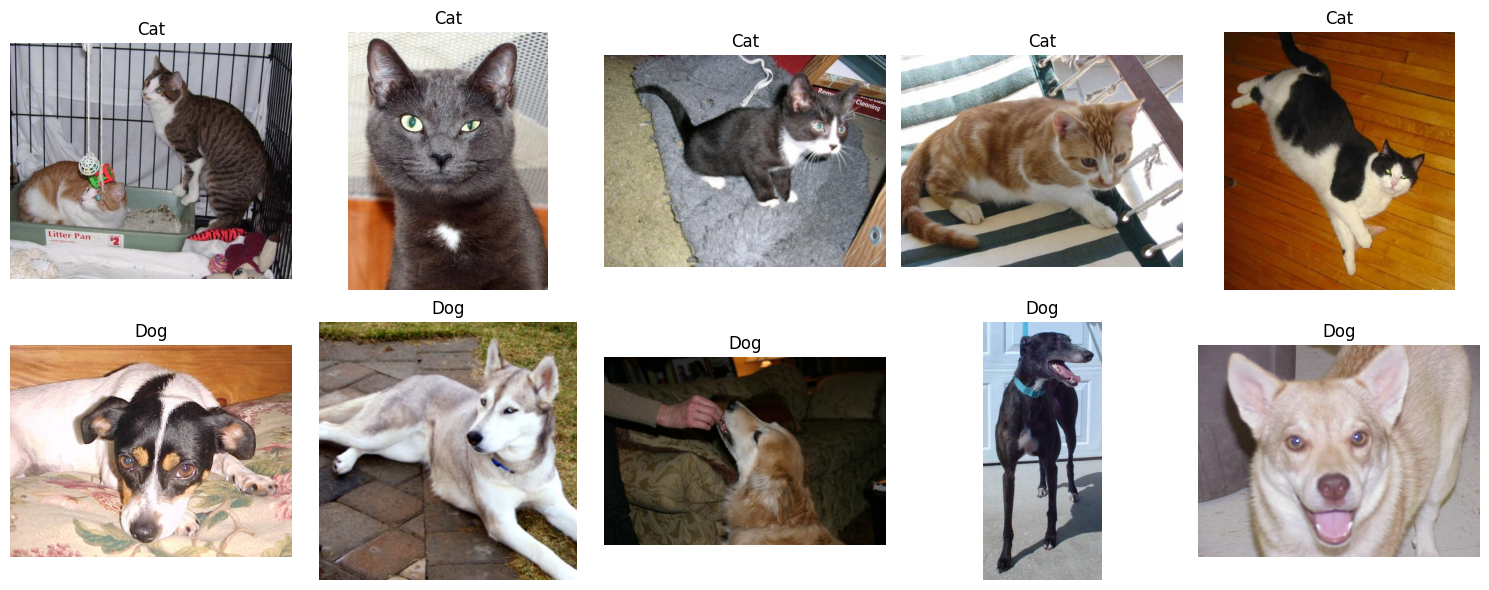

In [ ]:
import cv2

cat_path = os.path.join(pet_images_path, 'Cat')
dog_path = os.path.join(pet_images_path, 'Dog')

cat_files = [os.path.join(cat_path, f) for f in os.listdir(cat_path)[:5]]
dog_files = [os.path.join(dog_path, f) for f in os.listdir(dog_path)[:5]]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, img_path in enumerate(cat_files + dog_files): #Loop untuk iterasi gambar cat & dog
    try:
        img = cv2.imread(img_path) #membaca gambar
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #mengubah gambar BGR menjadi RGB
        axes[i].imshow(img) #display gambar
        axes[i].set_title(os.path.basename(os.path.dirname(img_path))) #Title dari directory gambar
        axes[i].axis('off')
    except Exception as e:
        print(f"Error loading image {img_path}: {e}")
        axes[i].set_title("Error")
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#List kosong menyimpan data gambar dan label
data = []
labels = []

for category, path in enumerate([cat_path, dog_path]): #Loop untuk pemberian index (cat=0,dog,1)
    for file in os.listdir(path):
        file_path = os.path.join(path, file)
        if os.path.isfile(file_path):
            data.append(file_path) #file ditambah ke list data
            labels.append(category) #kategori ditambah ke list labels

In [ ]:
df = pd.DataFrame({'image_data': data, 'label': labels})
display(df.tail())

,image_data,label
24997,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,1
24998,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,1
24999,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,1
25000,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,1
25001,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,1


In [ ]:
print(data[24000])
print(labels[24000])

/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/8257.jpg
1


In [ ]:
print(len(data))
print(len(labels))

25002
25002


In [ ]:
#Shuffle urutan dataframe
df = pd.DataFrame()
df['images'] = data
df['label'] = labels
df = df.sample(frac=1).reset_index(drop=True)
df.head(10)

,images,label
0,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
1,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
2,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
3,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,1
4,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
5,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
6,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,1
7,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
8,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
9,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0


## Data Cleaning

In [ ]:
# Melihat gambar yang rusak/corrupted
import PIL
l = []
for image in df['images']:
    try:
        img = PIL.Image.open(image)
    except:
        l.append(image)
l

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


['/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/Thumbs.db',
 '/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/Thumbs.db',
 '/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/11702.jpg',
 '/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg']

In [ ]:
# Menghapus file yang rusak
df = df[df['images']!='/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg']
df = df[df['images']!='/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/Thumbs.db']
df = df[df['images']!='/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/Thumbs.db']
df = df[df['images']!='/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/11702.jpg']
len(df)

24998

In [ ]:
#Mengubah tipe data label menjadi string, karena ImageDataGenerator hanya menerima label string
df['label'] = df['label'].astype('str')

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
print("Total data :", len(df))
print("Data train :", len(train))
print("Data test  :", len(test))

Total data : 24998
Data train : 19998
Data test  : 5000


## Data Augmentation


In [ ]:
#Memvariasikan Gambar
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_generator = ImageDataGenerator(
    rescale = 1./255,          # Normalisasi piksel menjadi range 0-1
    rotation_range = 40,       # Memutar gambar hingga 40 derajat
    shear_range = 0.2,         # Distorsi miring hingga 20%
    zoom_range = 0.2,          # Memperbesar/memperkecil gambar sebanyak 20%
    horizontal_flip = True,    # Membalik gambar secara horizontal
    fill_mode = 'nearest'      # Area kosong pasca augmentasi akan diisi nilai piksel terdekat
)

val_generator = ImageDataGenerator(rescale = 1./255)

train_iterator = train_generator.flow_from_dataframe(
    train,
    x_col='images',            # Kolom path gambar
    y_col='label',             # Kolom berisi label
    target_size=(128,128),     # Mengubah ukuran semua gambar
    batch_size=512,            # Jumlah gambar dalam setiap batch
    class_mode='binary'        # Klasifikasi Biner (0/1)
)

val_iterator = val_generator.flow_from_dataframe(
    test,
    x_col='images',
    y_col='label',
    target_size=(128,128),
    batch_size=512,
    class_mode='binary'
)

Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


## Model

In [ ]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization


model = Sequential()
model.add(Conv2D(32, (3,3), padding = 'same', activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), padding = 'same', activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3,3), padding = 'valid', activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))





/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)




*   Terdapat 3 blok Convolutional Layer dan Fully Connected layer
* Input awal 128 X 128 RGB


1.    Convolutional Layer: Menangkap pola lokal (tepi, sudut, tekstur) dengan kernel 3x3, menggunakan padding 'same' untuk mempertahankan piksel dan menggunakan pading 'valid' di akhir untuk mengeliminasi piksel tepi dan sedikit mengecilkan feature map.
2.   Maxpooling ukuran 2x2 sehingga menghasilkan angka maksimum dari blok layer, Mengurangi dimensi spasial.
3. Dropout: di awal sebanyak 25% dan diakhir sebanyak 50% untuk mencegah overfitting.
4. Flatten: mengubah peta fitur 3D menjadi vektor 1D agar dapat masuk ke dense layer.
5. Dense(128,ReLU) : Mempelajari kombinasi non-linear untuk klasifikasi.
6. Dense(1,Sigmoid) : Klasifikasi biner (0/1)






In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,843,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,899,777 (7.25 MB)

 Trainable params: 1,899,777 (7.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_iterator, epochs=15, validation_data=val_iterator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
25/40 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.5031 - loss: 0.8752

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


40/40 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.5071 - loss: 0.8246 - val_accuracy: 0.5700 - val_loss: 0.6905
Epoch 2/15
 6/40 ━━━━━━━━━━━━━━━━━━━━ 1:46 3s/step - accuracy: 0.5613 - loss: 0.6888

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


40/40 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.5561 - loss: 0.6861 - val_accuracy: 0.6128 - val_loss: 0.6538
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.6146 - loss: 0.6507 - val_accuracy: 0.6776 - val_loss: 0.6006
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.6733 - loss: 0.6034 - val_accuracy: 0.7100 - val_loss: 0.5609
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.6883 - loss: 0.5842 - val_accuracy: 0.7258 - val_loss: 0.5396
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.7060 - loss: 0.5614 - val_accuracy: 0.6956 - val_loss: 0.5842
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.7154 - loss: 0.5456 - val_accuracy: 0.7136 - val_loss: 0.5683
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.7318 - loss: 0.5330 - val_accuracy: 0.7484 - val_loss: 0.5105
Epoch 9/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.7441 - loss: 0.5194 - val_accuracy: 0.7676 - val_loss: 0.

In [ ]:
test_loss, test_acc = model.evaluate(val_iterator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7915 - loss: 0.4612
Test Accuracy: 0.7946000099182129
Test Loss: 0.45111268758773804


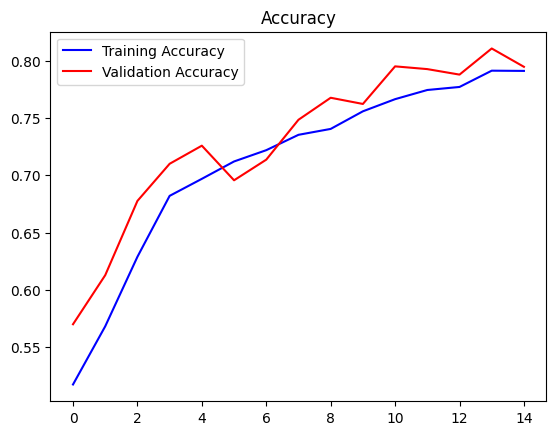

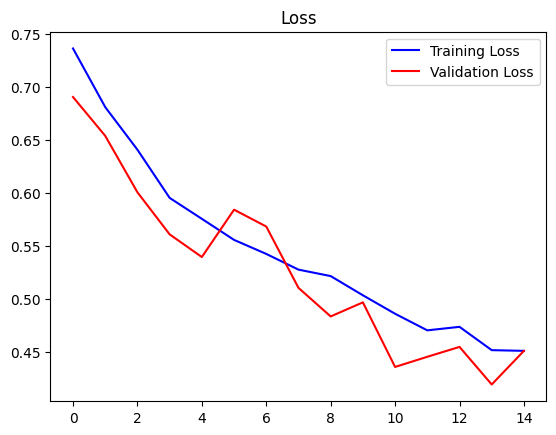

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

## Analisis Model

Model menunjukkan peningkatan kinerja yang stabil selama 15 epoch, baik dalam hal akurasi yang meningkat maupun loss yang menurun. Kesenjangan antara akurasi pelatihan dan validasi, serta loss pelatihan dan validasi, tidak terlalu besar, yang menunjukkan bahwa model tidak mengalami overfitting yang signifikan pada data pelatihan. Akurasi validasi akhir sekitar 79.5% menunjukkan bahwa model cukup baik dalam mengklasifikasikan gambar kucing dan anjing pada data yang belum pernah dilihat sebelumnya. Terdapat sedikit fluktuasi pada akurasi validasi dan loss validasi, pelu adanya peningkatan lanjut dengan hyperparameter tuning atau modifikasi arsitektur modelnya.

In [ ]:
from sklearn.metrics import classification_report

val_iterator.reset()
y_true = test['label'].iloc[val_iterator.index_array].astype(int)
y_pred_prob = model.predict(val_iterator)
y_pred = (y_pred_prob > 0.5).astype(int)
class_names = list(val_iterator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names)

print("Classification Report:")
print(report)

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 948ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.87      0.81      2465
           1       0.85      0.72      0.78      2535

    accuracy                           0.79      5000
   macro avg       0.80      0.80      0.79      5000
weighted avg       0.80      0.79      0.79      5000



Pada kelas Kucing:


*  Precision: Dari semua gambar yang diprediksi sebagai Kucing oleh model, 75% di antaranya benar-benar Kucing.
*   Recall: Dari semua gambar Kucing yang sebenarnya ada di dataset validasi, 87% di antaranya berhasil diprediksi dengan benar sebagai Kucing.
*   F1-score: Rata-rata dari precision dan recall dari kelas Kucing 81%.

Pada kelas Anjing:


*   Precision: Dari semua gambar yang diprediksi sebagai Anjing oleh model, 85% di antaranya benar-benar Anjing.

*   Recall: Dari semua gambar Anjing yang sebenarnya ada di dataset validasi, 72% di antaranya berhasil diprediksi dengan benar sebagai Anjing.
*   F1-score: Rata-rata dari precision dan recall dari kelas Anjing 78%.







In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cats_vs_dogs_1.h5 to cats_vs_dogs_1.h5


##Prediction From Google Images

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  uploaded_file_name = fn

Saving kucing_ireng.jpg to kucing_ireng.jpg
User uploaded file "kucing_ireng.jpg" with length 102106 bytes


In [ ]:
import tensorflow as tf
from tensorflow import keras

model = keras.models.load_model("cats_vs_dogs_1.h5")

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

image_path = uploaded_file_name
img = load_img(image_path, target_size=(128, 128))
img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
predictions = model.predict(img_array)

if predictions[0] > 0.5:
    predicted_label = 'Dog'
else:
    predicted_label = 'Cat'

print(f"Gambar '{image_path}' Predicted: {predicted_label}")
print(f"Prediction Value: {predictions[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
Gambar 'kucing_ireng.jpg' Predicted: Cat
Prediction Value: [0.07255173]


In [ ]:
model1 = 'cats_vs_dogs_1.h5'
model.save(model1)

In [ ]:
from google.colab import files
files.download("cats_vs_dogs_1.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Prediction From Test Data

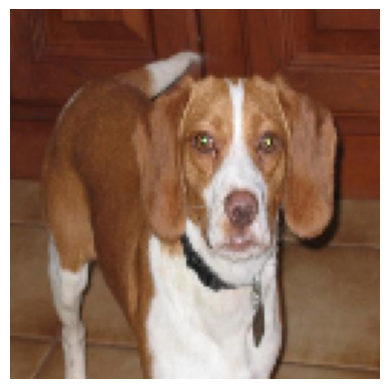

NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

image_path = test.sample()['images'].iloc[0]
img = load_img(image_path, target_size=(128, 128))

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
predictions = model.predict(img_array)

if predictions[0] > 0.5:
    pred_label= 'Dog'
else:
    pred_label = 'Cat'

print(f"Gambar '{image_path}' Predicted: {pred_label}")
print(f"Prediction Value: {predictions[0]}")

# Pre-Trained Model: InceptionV3

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

In [ ]:
IMG_SHAPE = (128,128,3)

# Base model
base_model = InceptionV3(input_shape=IMG_SHAPE, weights='imagenet', include_top=False)
base_model.trainable = False

# Functional API
inputs = layers.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)  # pastikan training=False karena freeze
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model2 = models.Model(inputs, outputs)
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 2, 2, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,804,833 (83.18 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 21,802,784 (83.17 MB)



1.   Base Model: InceptionV3
Berfungsi sebagai ekstraktor fitur yang sudah dilatih pada dataset besar.

2.   GlobalAveragePooling2D: Merata-ratakan feature map menjadi 1 nilai per channel, mengurangi parameter drastis dibanding Flatten.
3. Dropout: Sebanyak 20% untuk mencegah overfitting.

4. Dense(1,sigmoid): klasifikasi biner (probabilitas 0–1).

In [ ]:
history2 = model2.fit(train_iterator, epochs=10, validation_data=val_iterator)

Epoch 1/10
33/40 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6599 - loss: 0.8680

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


40/40 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.6806 - loss: 0.8151 - val_accuracy: 0.9156 - val_loss: 0.2061
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.8668 - loss: 0.3319 - val_accuracy: 0.9270 - val_loss: 0.1773
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.8768 - loss: 0.3019 - val_accuracy: 0.9294 - val_loss: 0.1754
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.8838 - loss: 0.2836 - val_accuracy: 0.9354 - val_loss: 0.1600
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8894 - loss: 0.2662 - val_accuracy: 0.9344 - val_loss: 0.1620
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.8965 - loss: 0.2507 - val_accuracy: 0.9390 - val_loss: 0.1524
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.8960 - loss: 0.2444 - val_accuracy: 0.9398 - val_loss: 0.1468
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.8964 - loss: 0.2502 - val_accuracy: 0.9408 - val_loss: 0.

In [ ]:
test_loss, test_acc = model2.evaluate(val_iterator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 986ms/step - accuracy: 0.9445 - loss: 0.1353
Test Accuracy: 0.9430000185966492
Test Loss: 0.14222469925880432


In [ ]:
model2.save('cats_vs_dogs.keras')

In [ ]:
from google.colab import files
files.download("cats_vs_dogs.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.figure()

loss = history2.history['loss']
val_loss = history2.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

Analisis Model Pre-Trained Inceptionv3

Model pre-trained mencapai akurasi validasi yang jauh lebih tinggi (sekitar 93.76%) dan loss validasi yang jauh lebih rendah (sekitar 0.157) hanya dalam 10 epoch, menunjukkan kinerja yang jauh lebih baik dibandingkan model pertama. Kesenjangan antara akurasi pelatihan dan validasi, serta loss pelatihan dan validasi relatif kecil dan stabil di sebagian besar epoch. Ini menunjukkan bahwa model ini sangat kuat dan tidak menunjukkan tanda-tanda overfitting yang signifikan.

In [ ]:
from sklearn.metrics import classification_report

val_iterator.reset()
y_true2 = test['label'].iloc[val_iterator.index_array].astype(int)
y_pred_prob2 = model2.predict(val_iterator)
y_pred2 = (y_pred_prob2 > 0.5).astype(int)
class_names = list(val_iterator.class_indices.keys())
report = classification_report(y_true2, y_pred2, target_names=class_names)

print("Classification Report:")
print(report)

Pada kelas Kucing:


*  Precision: Dari semua gambar yang diprediksi sebagai Kucing oleh model, 94% di antaranya benar-benar Kucing.
*   Recall: Dari semua gambar Kucing yang sebenarnya ada di dataset validasi, 93% di antaranya berhasil diprediksi dengan benar sebagai Kucing.
*   F1-score: Rata-rata dari precision dan recall dari kelas Kucing 94%.

Pada kelas Anjing:


*   Precision: Dari semua gambar yang diprediksi sebagai Anjing oleh model, 93% di antaranya benar-benar Anjing.

*   Recall: Dari semua gambar Anjing yang sebenarnya ada di dataset validasi, 95% di antaranya berhasil diprediksi dengan benar sebagai Anjing.
*   F1-score: Rata-rata dari precision dan recall dari kelas Anjing 94%.



In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

image_path = test.sample()['images'].iloc[0]
img = load_img(image_path, target_size=(128, 128))

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
predictions = model2.predict(img_array)

if predictions[0] > 0.5:
    pred_label= 'Dog'
else:
    pred_label = 'Cat'

print(f"Gambar '{image_path}' Predicted: {pred_label}")
print(f"Prediction Value: {predictions[0]}")

In [ ]:
model_incept = 'cats_vs_dogs_2.h5'
model2.save(model_incept)

In [ ]:
from google.colab import files
files.download("cats_vs_dogs_2.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>